In [1]:
!gdown --id "1JnC5mPCtSaI-NC_oUUs0_HSpEX35FUkn"


/usr/local/lib/python3.7/dist-packages/gdown/cli.py:131: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  category=FutureWarning,
Downloading...
From: https://drive.google.com/uc?id=1JnC5mPCtSaI-NC_oUUs0_HSpEX35FUkn
To: /content/data.csv
100% 358k/358k [00:00<00:00, 23.7MB/s]


In [2]:
import pandas as pd 
import itertools
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

In [ ]:
df=pd.read_csv('/Users/mac/Personal/learning_zone/Projects/End to end Weather Forecast/Temprature-Forecast-using-Microsoft-Azure/data/106.809947;10.876685.csv',parse_dates=True)
df=df[:8036]
df['DATE']=pd.to_datetime(df['DATE'])
df.set_index(keys='DATE',inplace=True)
data=df[['T2M']]
data


,T2M
DATE,
2000-01-01,25.51
2000-01-02,25.76
2000-01-03,25.76
2000-01-04,25.87
2000-01-05,26.12
...,...
2021-12-27,26.42
2021-12-28,25.58
2021-12-29,25.67


In [4]:

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)
WINDOW_SIZE = 5
X1, y1 = df_to_X_y(data, WINDOW_SIZE)
X1=X1.reshape(8031, 5, 1)
y1=y1.reshape(8031,)
X1.shape, y1.shape

((8031, 5, 1), (8031,))

In [5]:
X_train1, y_train1 = X1[:7000], y1[:7000]
X_val1, y_val1 = X1[7000:7500], y1[7000:7500]
X_test1, y_test1 = X1[7500:], y1[7500:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((7000, 5, 1), (7000,), (500, 5, 1), (500,), (531, 5, 1), (531,))

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((5, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 8)                 520       
                                                                 
 dense_1 (Dense)             (None, 1)                 9         
                                                                 
Total params: 17,425
Trainable params: 17,425
Non-trainable params: 0
_________________________________________________________________


In [7]:
cp1 = ModelCheckpoint('model1/', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [8]:
history=model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp1])

Epoch 1/10
6984/7000 [============================>.] - ETA: 0s - loss: 50.6304 - root_mean_squared_error: 7.1155

INFO:tensorflow:Assets written to: model1/assets


INFO:tensorflow:Assets written to: model1/assets


7000/7000 [==============================] - 34s 4ms/step - loss: 50.5158 - root_mean_squared_error: 7.1074 - val_loss: 1.8314 - val_root_mean_squared_error: 1.3533
Epoch 2/10
6986/7000 [============================>.] - ETA: 0s - loss: 0.5912 - root_mean_squared_error: 0.7689

INFO:tensorflow:Assets written to: model1/assets


...

INFO:tensorflow:Assets written to: model1/assets


7000/7000 [==============================] - 23s 3ms/step - loss: 0.4130 - root_mean_squared_error: 0.6426 - val_loss: 0.3709 - val_root_mean_squared_error: 0.6090
Epoch 8/10
7000/7000 [==============================] - 20s 3ms/step - loss: 0.4094 - root_mean_squared_error: 0.6399 - val_loss: 0.3771 - val_root_mean_squared_error: 0.6141
Epoch 9/10
7000/7000 [==============================] - ETA: 0s - loss: 0.4096 - root_mean_squared_error: 0.6400

INFO:tensorflow:Assets written to: model1/assets


INFO:tensorflow:Assets written to: model1/assets


7000/7000 [==============================] - 23s 3ms/step - loss: 0.4096 - root_mean_squared_error: 0.6400 - val_loss: 0.3624 - val_root_mean_squared_error: 0.6020
Epoch 10/10
7000/7000 [==============================] - 18s 3ms/step - loss: 0.4085 - root_mean_squared_error: 0.6392 - val_loss: 0.3635 - val_root_mean_squared_error: 0.6029


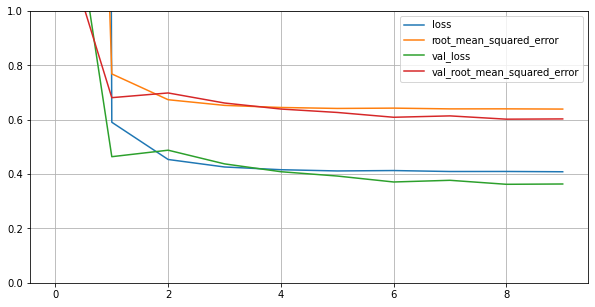

In [9]:
pd.DataFrame(history.history).plot(figsize=(10, 5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [10]:
from tensorflow.keras.models import load_model
model1 = load_model('model1/')

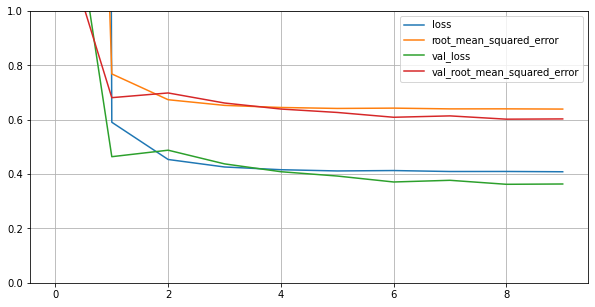

In [11]:
pd.DataFrame(history.history).plot(figsize=(10, 5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [12]:
train_predictions = model1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})
train_results

,Train Predictions,Actuals
0,26.161890,25.13
1,25.322451,25.58
2,25.808933,25.87
3,25.933256,24.64
4,24.914717,25.55
...,...,...
6995,29.086569,28.65
6996,28.693911,28.33
6997,28.422632,28.04
6998,28.110147,27.81


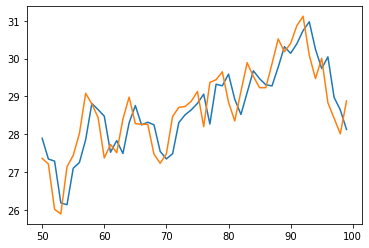

In [13]:
import matplotlib.pyplot as plt
train_results['Train Predictions'][50:100].plot()
train_results['Actuals'][50:100].plot()

In [14]:
test_predictions = model1.predict(X_test1).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1})
test_results

,Test Predictions,Actuals
0,27.120401,28.12
1,27.966108,27.46
2,27.366880,27.34
3,27.392166,27.81
4,27.753496,27.61
...,...,...
526,26.411760,26.42
527,26.400549,25.58
528,25.731915,25.67
529,25.879740,25.49


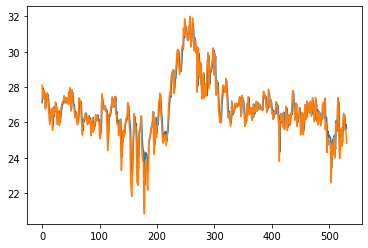

In [15]:
plt.plot(test_results['Test Predictions'])
plt.plot(test_results['Actuals'])

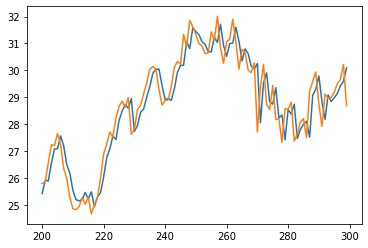

In [16]:
plt.plot(test_results['Test Predictions'][200:300])
plt.plot(test_results['Actuals'][200:300])

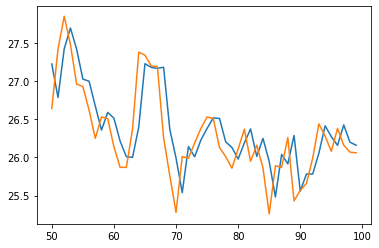

In [19]:
plt.plot(test_results['Test Predictions'][50:100])
plt.plot(test_results['Actuals'][50:100])

In [17]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(test_results['Test Predictions'],test_results['Actuals']))

0.41847409186885903
